In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', None)


### Identify the data set

In [118]:
# Load the dataset
df = pd.read_csv('../data/loan_dataset.csv')
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,7,40833.47,24302.07,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,5,27968.01,10803.01,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,2,15502.25,4505.44,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,7,18157.79,5525.63,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,1,17467.56,3593.91,2,1


In [119]:
# Replace spaces with underscores in column names
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].str.replace(' ', '_').str.strip().str.lower()
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,num_of_delinquencies,loan_paid_back
0,59,male,married,master's,24240.19,2020.02,employed,0.074,743,17173.72,car,13.39,36,581.88,7,40833.47,24302.07,1,1
1,72,female,married,bachelor's,20172.98,1681.08,employed,0.219,531,22663.89,debt_consolidation,17.81,60,573.17,5,27968.01,10803.01,3,1
2,49,female,single,high_school,26181.80,2181.82,employed,0.234,779,3631.36,business,9.53,60,76.32,2,15502.25,4505.44,0,1
3,35,female,single,high_school,11873.84,989.49,employed,0.264,809,14939.23,other,7.99,36,468.07,7,18157.79,5525.63,5,1
4,63,other,single,other,25326.44,2110.54,employed,0.260,663,16551.71,car,15.20,60,395.50,1,17467.56,3593.91,2,1


In [120]:
# Shape of the dataset
print(f'Shape of the dataset: {df.shape}')
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Shape of the dataset: (20000, 19)
Number of rows: 20000
Number of columns: 19


In [121]:
# Data types of the columns
print('\nData types of the columns:')
print(df.dtypes)


Data types of the columns:
age                       int64
gender                   object
marital_status           object
education_level          object
annual_income           float64
monthly_income          float64
employment_status        object
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose             object
interest_rate           float64
loan_term                 int64
installment             float64
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object


In [122]:
# Missing values in the dataset
print('\nMissing values in the dataset:')
print(df.isnull().sum())


Missing values in the dataset:
age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64


In [123]:
# Summary statistics of numerical columns
df.describe().T.style.background_gradient(cmap="Greens")

,count,mean,std,min,25%,50%,75%,max
age,20000.000000,48.027000,15.829352,21.000000,35.000000,48.000000,62.000000,75.000000
annual_income,20000.000000,43549.637765,28668.579671,6000.000000,24260.752500,36585.260000,54677.917500,400000.000000
monthly_income,20000.000000,3629.136466,2389.048326,500.000000,2021.730000,3048.770000,4556.495000,33333.330000
debt_to_income_ratio,20000.000000,0.177019,0.105059,0.010000,0.096000,0.160000,0.241000,0.667000
credit_score,20000.000000,679.256950,69.638580,373.000000,632.000000,680.000000,727.000000,850.000000
loan_amount,20000.000000,15129.300909,8605.405513,500.000000,8852.695000,14946.170000,20998.867500,49039.690000
interest_rate,20000.000000,12.400627,2.442729,3.140000,10.740000,12.400000,14.002500,22.510000
loan_term,20000.000000,43.222800,11.008380,36.000000,36.000000,36.000000,60.000000,60.000000
installment,20000.000000,455.625794,274.622125,9.430000,253.910000,435.595000,633.595000,1685.400000
num_of_open_accounts,20000.000000,5.011800,2.244529,0.000000,3.000000,5.000000,6.000000,15.000000


In [124]:
df.describe(include="object").T

,count,unique,top,freq
gender,20000,3,female,10034
marital_status,20000,4,single,9031
education_level,20000,5,bachelor's,8045
employment_status,20000,5,employed,13007
loan_purpose,20000,8,debt_consolidation,7981


### Target Variable + Feature Analysis

#### Define functions for visualization and stastical summery 

 - Target variable: - **loan_paid_back** 

In [125]:
# Function to plot histograms and boxplots for numerical variables
def plot_numerical_distribution(column):
    sns.set_style("darkgrid")
    plt.figure(figsize=(14, 6), dpi=100)

    # ── Histogram ────────────────────────────────────────────
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=column, kde=True, color='skyblue')

    # Draw mean line
    mean_val = df[column].mean()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')

    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.15)
    plt.legend()

    # ── Boxplot ───────────────────────────────────────────────
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='loan_paid_back', y=column ,     hue='loan_paid_back', legend=False,palette=["#FFCCA7", "#85D8FF"], saturation=0.85)

    # Annotate mean values on the boxplot
    group_means = df.groupby('loan_paid_back')[column].mean()
    for i, mean in enumerate(group_means):
        plt.text(
            i, mean, f'{mean:.2f}',
            ha='center', va='bottom',
            color='red', fontsize=14, fontweight='bold'
        )

    plt.title(f'Boxplot of {column} by Loan Status')
    plt.xlabel('Loan Paid Back')
    plt.ylabel(column)
    upper = df[column].quantile(0.99) * 1.1
    plt.ylim(0, upper)
    ax = plt.gca()
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Yes'])

    plt.tight_layout()
    plt.show()
    
# Function to plot count plots for categorical variables
def plot_categorical_distribution(column):
    sns.set_style("darkgrid")
    plt.figure(figsize=(8, 5), dpi=100)

    ax = sns.countplot(
        data=df,
        x=column,
        hue='loan_paid_back',
        hue_order=[1, 0],
        palette=["#85D8FF","#FFCCA7"], saturation=0.85
    )
    plt.title(f'Count Plot of {column} by Loan Status')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Loan Status', labels=['Paid','Not Paid'], loc='upper right', fontsize=10)
    plt.xticks(rotation=45,fontsize=12)
    plt.yticks(fontsize=10)

    # Increase y-axis limit
    ymax = ax.get_ylim()[1]
    plt.ylim(0, ymax * 1.15)   # add 15% extra space
    # add counts on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height <= 0:
            continue
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
    plt.show()


In [126]:
from scipy import stats as sp_stats
from scipy.stats import chi2_contingency

# Function to display summary statistics and distribution for numerical columns
def statistical_summary_for_numerical(column):
    desc = df[column].describe()          # ← renamed from 'stats' to 'desc'
    skewness = df[column].skew()
    group_means = df.groupby('loan_paid_back')[column].mean()

    # Statistical tests
    group0 = df[df['loan_paid_back'] == 0][column]
    group1 = df[df['loan_paid_back'] == 1][column]
    t_stat, p_value = sp_stats.ttest_ind(group0, group1, equal_var=False)
    corr, corr_p = sp_stats.pointbiserialr(df['loan_paid_back'], df[column])

    skew_label = (
        '(roughly symmetric)'   if abs(skewness) < 0.5 else
        '(moderate right skew)' if 0.5 <= skewness < 1.0 else
        '(high right skew)'     if skewness >= 1.0 else
        '(moderate left skew)'  if -1.0 < skewness <= -0.5 else
        '(high left skew)'
    )

    print(f"""
    {'─'*45}
    📊 Summary for '{column}'
    {'─'*45}
    Range     : {desc['min']:.2f}  →  {desc['max']:.2f}
    Mean      : {desc['mean']:.2f}
    Median    : {desc['50%']:.2f}
    Std Dev   : {desc['std']:.2f}
    IQR       : {desc['25%']:.2f}  →  {desc['75%']:.2f}
    Skewness  : {skewness:.2f}  {skew_label}
    {'─'*45}
    Loan NOT Paid (0) mean : {group_means[0]:.2f}
    Loan Paid     (1) mean : {group_means[1]:.2f}
    Difference            : {abs(group_means[1] - group_means[0]):.2f}
    {'─'*45}
    T-test p-value        : {p_value:.4f}  {'✅ Significant' if p_value < 0.05 else '❌ Not significant'}
    Point-biserial corr   : {corr:.4f}  (p={corr_p:.4f})
    {'─'*45}
    """)

# Function to display summary statistics and distribution for categorical columns
def statistical_summary_for_categorical(column):
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100
    group_dist = pd.crosstab(df['loan_paid_back'], df[column], normalize='columns') * 100

    # Chi-squared test
    contingency_table = pd.crosstab(df[column], df['loan_paid_back'])
    chi2, p_value, dof, expected  = chi2_contingency(contingency_table)
    if (expected < 5).any():
        print("⚠ Low expected cell counts — chi² may be unreliable")

    print(f"""
{'─'*50}
📊 Summary for '{column}'
{'─'*50}
Total Unique Values : {df[column].nunique()}
{'─'*50}
Value Distribution:""")

    for val, cnt, pct in zip(counts.index, counts.values, percentages.values):
        print(f"  {str(val):<15} Count: {cnt:<8} ({pct:.2f}%)")

    print(f"{'─'*50}")
    print("Distribution by Loan Status (%):")
    print()

    categories = counts.index.tolist()
    header = f"  {'Loan Status':<20}" + "".join(f"{str(c):<15}" for c in categories)
    print(header)
    print("  " + "·" * (len(header) - 2))

    labels = {0: "Not Paid (0)", 1: "Paid     (1)"}
    for status in [0, 1]:
        if status in group_dist.index:
            row = f"  {labels[status]:<20}"
            for cat in categories:
                val = group_dist.loc[status, cat] if cat in group_dist.columns else 0.0
                row += f"{val:.2f}%{'':<8}"
            print(row)

    print(f"""{'─'*50}
Chi-squared : {chi2:.4f}
p-value     : {p_value:.4f}  {'✅ Significant' if p_value < 0.05 else '❌ Not significant'}
Degrees of Freedom : {dof}
{'─'*50}
""")

#### 1. Distribution of Age 


    ─────────────────────────────────────────────
    📊 Summary for 'age'
    ─────────────────────────────────────────────
    Range     : 21.00  →  75.00
    Mean      : 48.03
    Median    : 48.00
    Std Dev   : 15.83
    IQR       : 35.00  →  62.00
    Skewness  : 0.01  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 47.77
    Loan Paid     (1) mean : 48.09
    Difference            : 0.32
    ─────────────────────────────────────────────
    T-test p-value        : 0.2573  ❌ Not significant
    Point-biserial corr   : 0.0080  (p=0.2580)
    ─────────────────────────────────────────────
    


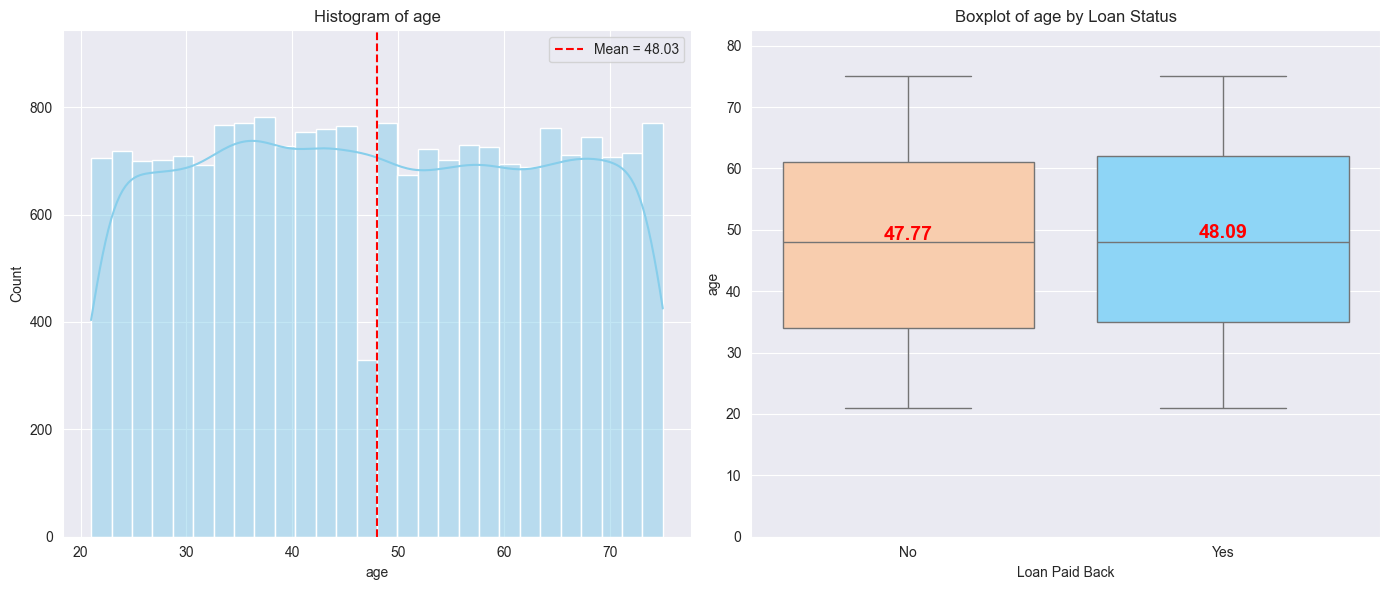

In [127]:
# Analyze 'age' column
statistical_summary_for_numerical('age')
plot_numerical_distribution('age')

##### 🔍 **Age** — Analysis Summary

- **Distribution** : Roughly uniform across ages 21–75, nearly perfect symmetry (skew = 0.01, Mean ≈ Median ≈ 48)
- **Spread** : Wide range (std = 15.83), age is well distributed across the dataset
- **vs Loan Status** : Mean age is almost identical between groups (47.77 vs 48.09), a difference of only 0.32
- **Statistical Test** : T-test p = 0.258 ❌ — difference between groups is not statistically significant
- **Correlation** : Point-biserial r = 0.008 — near-zero, confirms no linear relationship with loan repayment
- **Conclusion** : `age` has **no meaningful relationship** with loan repayment — not expected to be a useful predictor

#### 2. Distribution of Gender


──────────────────────────────────────────────────
📊 Summary for 'gender'
──────────────────────────────────────────────────
Total Unique Values : 3
──────────────────────────────────────────────────
Value Distribution:
  female          Count: 10034    (50.17%)
  male            Count: 9536     (47.68%)
  other           Count: 430      (2.15%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         female         male           other          
  ·································································
  Not Paid (0)        19.75%        20.25%        20.70%        
  Paid     (1)        80.25%        79.75%        79.30%        
──────────────────────────────────────────────────
Chi-squared : 0.8836
p-value     : 0.6429  ❌ Not significant
Degrees of Freedom : 2
──────────────────────────────────────────────────



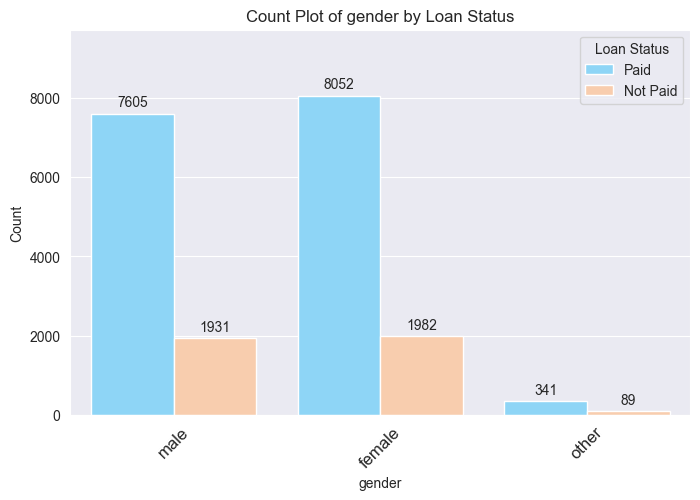

In [128]:
statistical_summary_for_categorical('gender')
plot_categorical_distribution('gender')

##### 🔍 **Gender** — Analysis Summary

- **Distribution** : Slightly female-dominated (50.17%), followed by Male (47.68%), with a small Other group (2.15%)
- **vs Loan Status** : Repayment rates are nearly identical across all genders — Paid rate: Female 50.33%, Male 47.54%, Other 2.13%
- **Statistical Test** : Chi-squared p = 0.643 ❌ — no statistically significant association between gender and loan repayment
- **Conclusion** : `gender` has **no meaningful relationship** with loan repayment — unlikely to contribute predictive power

#### 3. Distribution of marital_status


──────────────────────────────────────────────────
📊 Summary for 'marital_status'
──────────────────────────────────────────────────
Total Unique Values : 4
──────────────────────────────────────────────────
Value Distribution:
  single          Count: 9031     (45.16%)
  married         Count: 8974     (44.87%)
  divorced        Count: 1428     (7.14%)
  widowed         Count: 567      (2.83%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         single         married        divorced       widowed        
  ················································································
  Not Paid (0)        20.04%        19.97%        19.47%        21.52%        
  Paid     (1)        79.96%        80.03%        80.53%        78.48%        
──────────────────────────────────────────────────
Chi-squared : 1.0819
p-value     : 0.7815  ❌ Not significant
Degrees of Freedom : 3
──────────────────────────────────────────────────



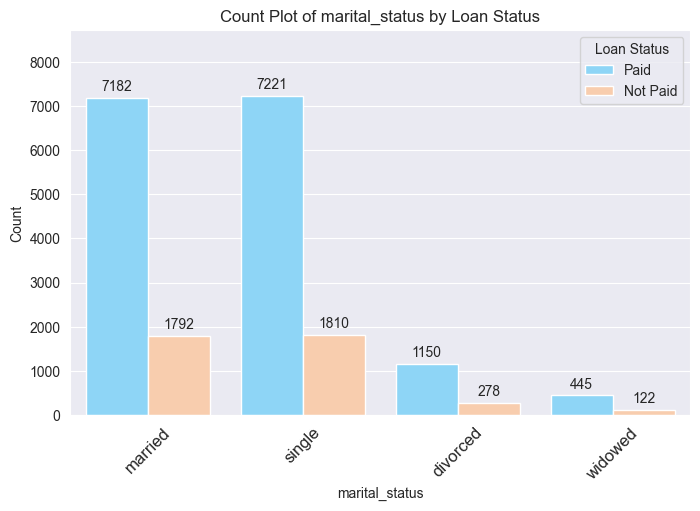

In [129]:
statistical_summary_for_categorical('marital_status')
plot_categorical_distribution('marital_status')

##### 🔍 **marital_status** — Analysis Summary

- **Distribution** : Single persons dominant(45.16%), followed by married(44.87%). 
- **vs Loan Status** : Repayment rates are nearly identical across all marital_status
- **Statistical Test** : Chi-squared p = 0.7815 ❌ — no statistically significant association between marital_status and loan repayment
- **Conclusion** : `marital_status` has **no meaningful relationship** with loan repayment — unlikely to contribute predictive power

#### 4. Distribution of education_level


──────────────────────────────────────────────────
📊 Summary for 'education_level'
──────────────────────────────────────────────────
Total Unique Values : 5
──────────────────────────────────────────────────
Value Distribution:
  bachelor's      Count: 8045     (40.23%)
  high_school     Count: 5919     (29.59%)
  master's        Count: 3724     (18.62%)
  other           Count: 1508     (7.54%)
  phd             Count: 804      (4.02%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         bachelor's     high_school    master's       other          phd            
  ·······························································································
  Not Paid (0)        20.87%        19.19%        20.22%        19.63%        17.16%        
  Paid     (1)        79.13%        80.81%        79.78%        80.37%        82.84%        
──────────────────────────────────────────────────
Chi-squared : 10.4980
p-value     : 0.0

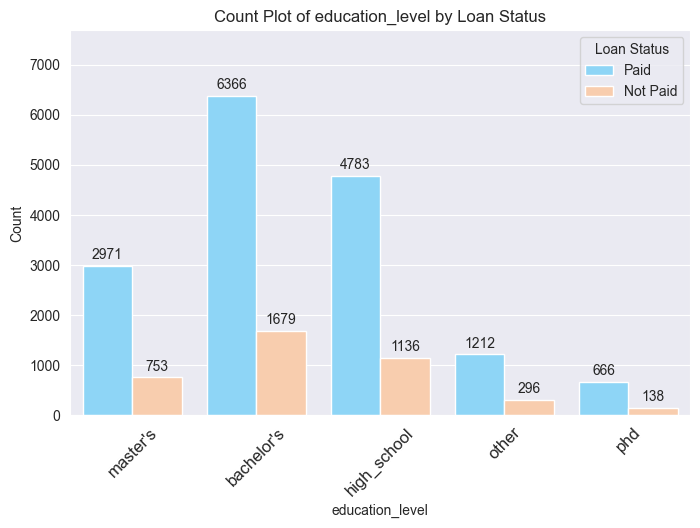

In [130]:
statistical_summary_for_categorical("education_level")
plot_categorical_distribution("education_level")

##### 🔍 **Education Level** — Analysis Summary

- **Distribution**: Bachelor's degree holders dominate the dataset (40.23%), followed by high school (29.59%), master's (18.62%), other (7.54%), and PhD being the smallest group (4.02%)
- **vs Loan Status**: Repayment rates are consistently high across all education levels — PhD holders lead slightly at 82.84% paid, while high school (80.81%), other (80.37%), master's (79.78%), and bachelor's (79.13%) follow closely behind
- **Statistical Test**: Chi-squared p = 0.0328 ✅ — a statistically significant association exists between education level and loan repayment
- **Conclusion**: `education_level` has a **weak but statistically significant relationship** with loan repayment — the effect is subtle (repayment rates only span ~4 percentage points across groups), but it may contribute marginal predictive power to a model

#### 5. Distribution of annual_income


    ─────────────────────────────────────────────
    📊 Summary for 'annual_income'
    ─────────────────────────────────────────────
    Range     : 6000.00  →  400000.00
    Mean      : 43549.64
    Median    : 36585.26
    Std Dev   : 28668.58
    IQR       : 24260.75  →  54677.92
    Skewness  : 2.33  (high right skew)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 43374.39
    Loan Paid     (1) mean : 43593.48
    Difference            : 219.09
    ─────────────────────────────────────────────
    T-test p-value        : 0.6770  ❌ Not significant
    Point-biserial corr   : 0.0031  (p=0.6655)
    ─────────────────────────────────────────────
    


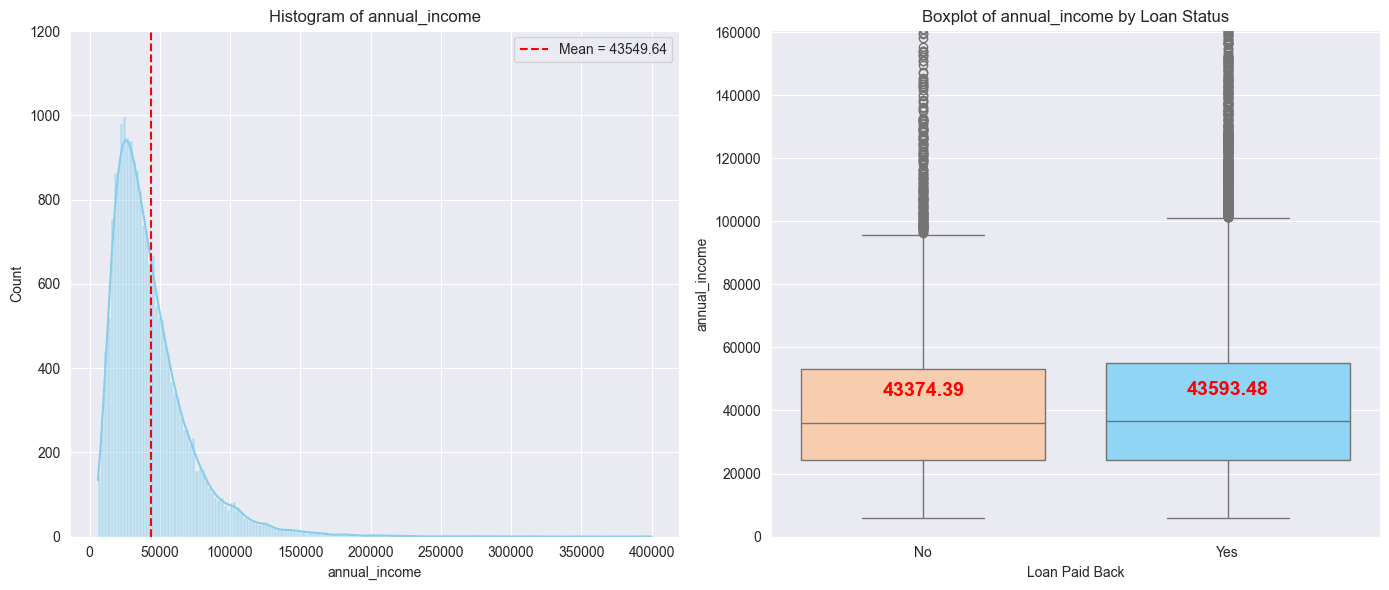

In [131]:
statistical_summary_for_numerical('annual_income')
plot_numerical_distribution('annual_income')


    ─────────────────────────────────────────────
    📊 Summary for 'annual_income_log'
    ─────────────────────────────────────────────
    Range     : 8.70  →  12.90
    Mean      : 10.50
    Median    : 10.51
    Std Dev   : 0.60
    IQR       : 10.10  →  10.91
    Skewness  : -0.02  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 10.49
    Loan Paid     (1) mean : 10.50
    Difference            : 0.01
    ─────────────────────────────────────────────
    T-test p-value        : 0.3223  ❌ Not significant
    Point-biserial corr   : 0.0070  (p=0.3229)
    ─────────────────────────────────────────────
    


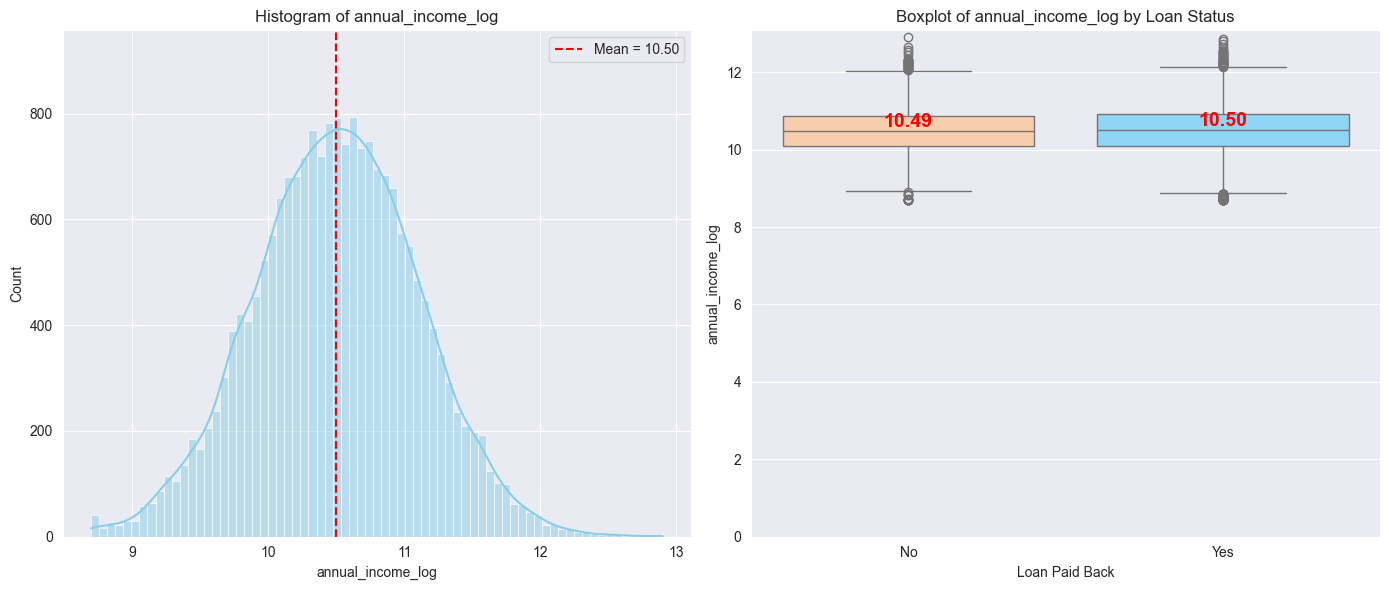

In [132]:
# Log-transform 'annual_income' to reduce skewness
annual_income_log = np.log1p(df['annual_income'])
df['annual_income_log'] = annual_income_log

statistical_summary_for_numerical('annual_income_log')
plot_numerical_distribution('annual_income_log')

##### 🔍 **Annual Income (Log-Transformed)** — Analysis Summary

- **Distribution** : After log transformation, distribution is now roughly symmetric (skew = -0.02, Mean ≈ Median ≈ 10.50) — a major improvement from the original skew of 2.33
- **Spread** : Compact and well-behaved (std = 0.60, IQR = 10.10 – 10.91), outliers significantly reduced compared to raw income
- **vs Loan Status** : Log-scale mean income is virtually identical between groups — Not Paid (10.49) vs Paid (10.50), a negligible difference of only 0.01
- **Statistical Test** : T-test p = 0.322 ❌ — difference between groups is not statistically significant
- **Correlation** : Point-biserial r = 0.007 — near-zero, confirms no linear relationship with loan repayment even after transformation
- **Conclusion** : `annual_income_log` has **no meaningful relationship** with loan repayment — log transformation successfully normalized the distribution (useful for modeling assumptions) but confirmed that income, in any form, carries no predictive signal for loan repayment in this dataset

#### 6. Distribution of monthly_income


    ─────────────────────────────────────────────
    📊 Summary for 'monthly_income'
    ─────────────────────────────────────────────
    Range     : 500.00  →  33333.33
    Mean      : 3629.14
    Median    : 3048.77
    Std Dev   : 2389.05
    IQR       : 2021.73  →  4556.49
    Skewness  : 2.33  (high right skew)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 3614.53
    Loan Paid     (1) mean : 3632.79
    Difference            : 18.26
    ─────────────────────────────────────────────
    T-test p-value        : 0.6770  ❌ Not significant
    Point-biserial corr   : 0.0031  (p=0.6655)
    ─────────────────────────────────────────────
    


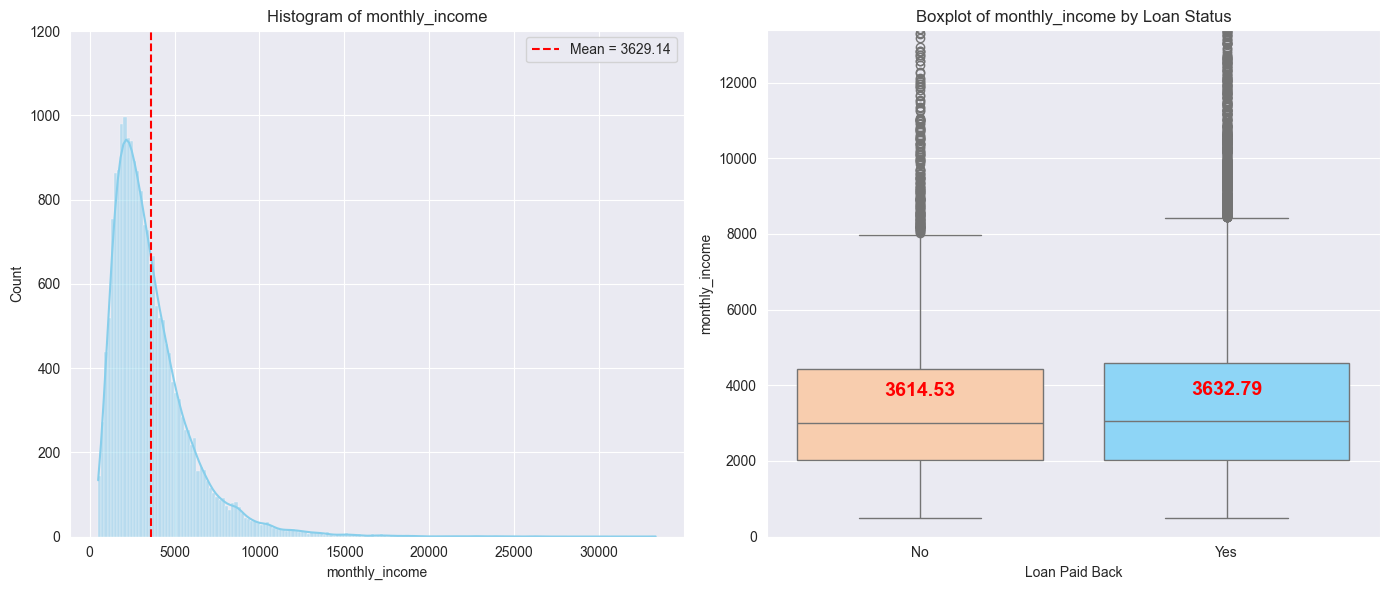

In [133]:
statistical_summary_for_numerical('monthly_income')
plot_numerical_distribution('monthly_income')


    ─────────────────────────────────────────────
    📊 Summary for 'monthly_income_log'
    ─────────────────────────────────────────────
    Range     : 6.22  →  10.41
    Mean      : 8.02
    Median    : 8.02
    Std Dev   : 0.60
    IQR       : 7.61  →  8.42
    Skewness  : -0.01  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 8.01
    Loan Paid     (1) mean : 8.02
    Difference            : 0.01
    ─────────────────────────────────────────────
    T-test p-value        : 0.3222  ❌ Not significant
    Point-biserial corr   : 0.0070  (p=0.3228)
    ─────────────────────────────────────────────
    


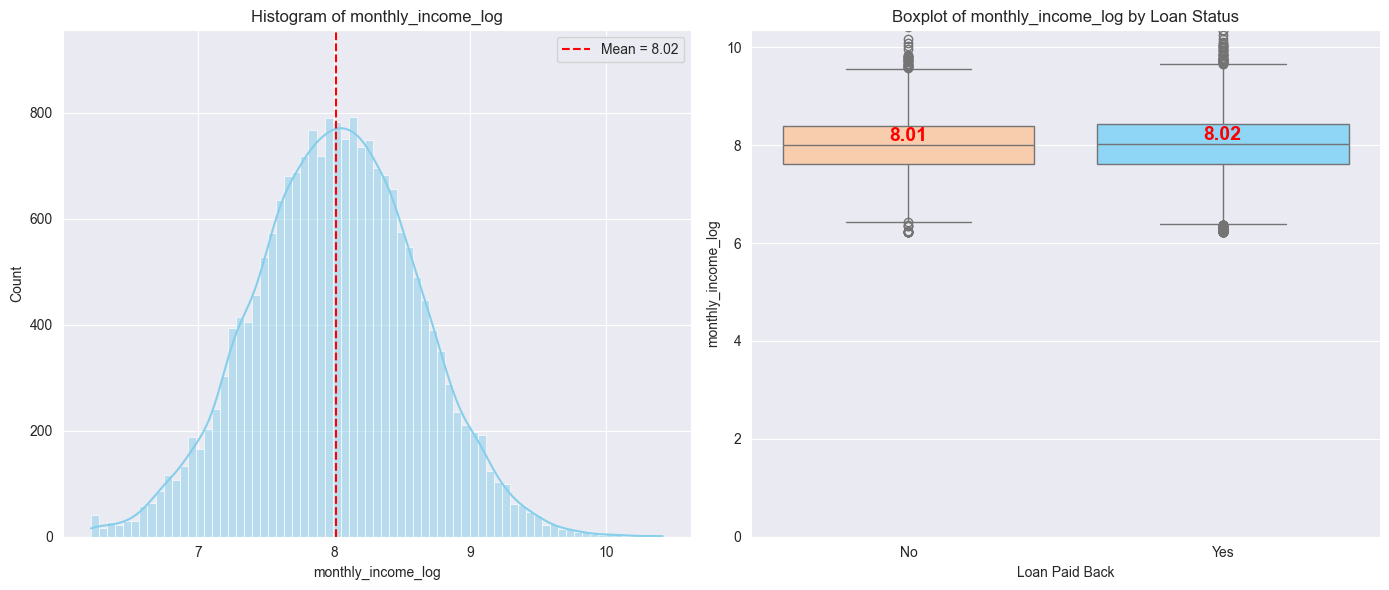

In [134]:
monthly_income_log = np.log1p(df['monthly_income'])
df['monthly_income_log'] = monthly_income_log
statistical_summary_for_numerical('monthly_income_log')
plot_numerical_distribution('monthly_income_log')

##### 🔍 **Monthly Income (Log-Transformed)** — Analysis Summary

- **Distribution** : After log transformation, distribution is now roughly symmetric (skew = -0.01, Mean ≈ Median ≈ 8.02)
- **Spread** : Compact and well-behaved (std = 0.60, IQR = 7.61  →  8.42), outliers significantly reduced compared to raw income
- **vs Loan Status** : Log-scale mean income is virtually identical between groups — Not Paid (8.01) vs Paid (8.02), a negligible difference of only 0.01
- **Statistical Test** : T-test p = 0.322 ❌ — difference between groups is not statistically significant
- **Correlation** : Point-biserial r = 0.007 — near-zero, confirms no linear relationship with loan repayment even after transformation
- **Conclusion** : `monthly_income_log` has **no meaningful relationship** with loan repayment — log transformation successfully normalized the distribution (useful for modeling assumptions) but confirmed that income, in any form, carries no predictive signal for loan repayment in this dataset

#### 7. Distribution of employment_status


──────────────────────────────────────────────────
📊 Summary for 'employment_status'
──────────────────────────────────────────────────
Total Unique Values : 5
──────────────────────────────────────────────────
Value Distribution:
  employed        Count: 13007    (65.03%)
  self-employed   Count: 2923     (14.62%)
  unemployed      Count: 2113     (10.56%)
  retired         Count: 1176     (5.88%)
  student         Count: 781      (3.91%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         employed       self-employed  unemployed     retired        student        
  ·······························································································
  Not Paid (0)        11.30%        11.43%        81.83%        0.51%        59.28%        
  Paid     (1)        88.70%        88.57%        18.17%        99.49%        40.72%        
──────────────────────────────────────────────────
Chi-squared : 6827.4041
p-value     : 

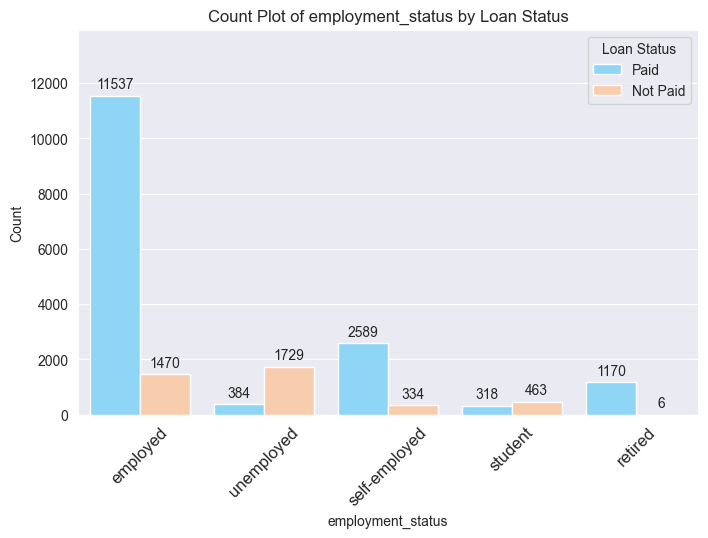

In [135]:
statistical_summary_for_categorical('employment_status')
plot_categorical_distribution('employment_status')

##### 🔍 **Employment Status** — Analysis Summary

- **Distribution** : Heavily dominated by employed borrowers (65.03%), followed by self-employed (14.62%), unemployed (10.56%), retired (5.88%), and students (3.91%)
- **vs Loan Status** : Repayment rates vary dramatically across groups — Retired (99.49%) and Employed (88.70%) show excellent repayment, while Students (40.72%) and Unemployed (18.17%) show alarmingly poor repayment
- **Key Pattern** : A clear employment-stability trend emerges — borrowers with **stable/active income sources** (Retired, Employed, Self-employed) repay at 88–99%, while borrowers **without stable income** (Students, Unemployed) default at alarming rates of 59% and 82% respectively — suggesting employment stability is a strong proxy for repayment capacity
- **Statistical Test** : Chi-squared p = 0.0000 ✅ — extremely strong statistically significant association with loan repayment
- **Effect Size** : Cramér's V ≈ 0.292 — moderate-to-strong effect, confirming this is not just statistically significant but practically meaningful
- **Conclusion** : `employment_status` has a **strong and meaningful relationship** with loan repayment — one of the most predictive features found so far, expected to contribute significant predictive power to the model

#### 8. Distribution of debt_to_income_ratio


    ─────────────────────────────────────────────
    📊 Summary for 'debt_to_income_ratio'
    ─────────────────────────────────────────────
    Range     : 0.01  →  0.67
    Mean      : 0.18
    Median    : 0.16
    Std Dev   : 0.11
    IQR       : 0.10  →  0.24
    Skewness  : 0.79  (moderate right skew)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 0.22
    Loan Paid     (1) mean : 0.17
    Difference            : 0.06
    ─────────────────────────────────────────────
    T-test p-value        : 0.0000  ✅ Significant
    Point-biserial corr   : -0.2238  (p=0.0000)
    ─────────────────────────────────────────────
    


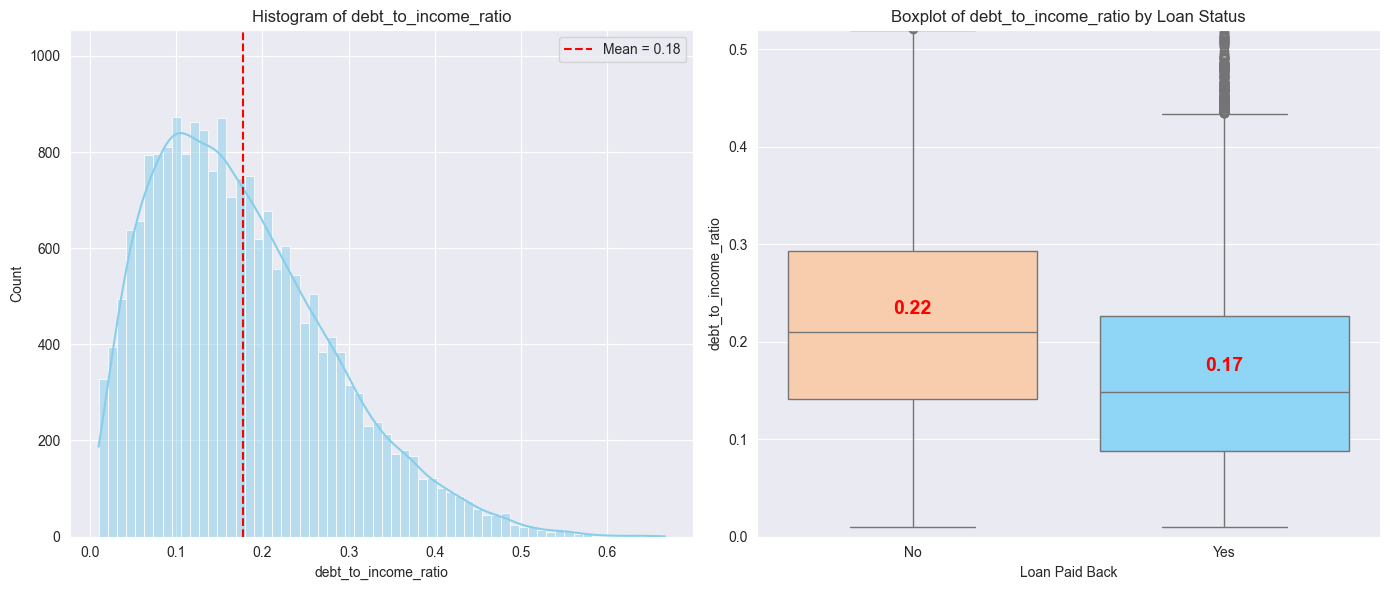

In [136]:
statistical_summary_for_numerical('debt_to_income_ratio')
plot_numerical_distribution('debt_to_income_ratio')

##### 🔍 **Debt-to-Income Ratio** — Analysis Summary

- **Distribution** : Moderately right-skewed (skew = 0.79), ranging from 0.01 to 0.67 with mean (0.18) slightly above median (0.16) — relatively well-behaved compared to raw income
- **Spread** : Moderate dispersion (std = 0.11, IQR = 0.10 – 0.24), concentrated in the lower ratio range
- **vs Loan Status** : Clear separation between groups — Not Paid mean (0.22) vs Paid mean (0.17), a meaningful difference of 0.05; higher debt burden visibly associated with default
- **Key Pattern** : Intuitive and expected — borrowers carrying **higher debt relative to income** are more likely to default, confirming that financial overextension is a repayment risk signal
- **Statistical Test** : T-test p = 0.0000 ✅ — difference between groups is highly statistically significant
- **Correlation** : Point-biserial r = -0.224 — moderate negative relationship, meaning higher debt-to-income ratio is associated with lower likelihood of repayment
                   `↑ debt-to-income ratio → ↓ probability of repayment`
- **Conclusion** : `debt_to_income_ratio` has a **meaningful and statistically strong relationship** with loan repayment — one of the stronger numerical predictors found so far, expected to be a valuable feature in modeling

#### 9. Distribution of credit_score


    ─────────────────────────────────────────────
    📊 Summary for 'credit_score'
    ─────────────────────────────────────────────
    Range     : 373.00  →  850.00
    Mean      : 679.26
    Median    : 680.00
    Std Dev   : 69.64
    IQR       : 632.00  →  727.00
    Skewness  : -0.07  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 651.43
    Loan Paid     (1) mean : 686.22
    Difference            : 34.78
    ─────────────────────────────────────────────
    T-test p-value        : 0.0000  ✅ Significant
    Point-biserial corr   : 0.1998  (p=0.0000)
    ─────────────────────────────────────────────
    


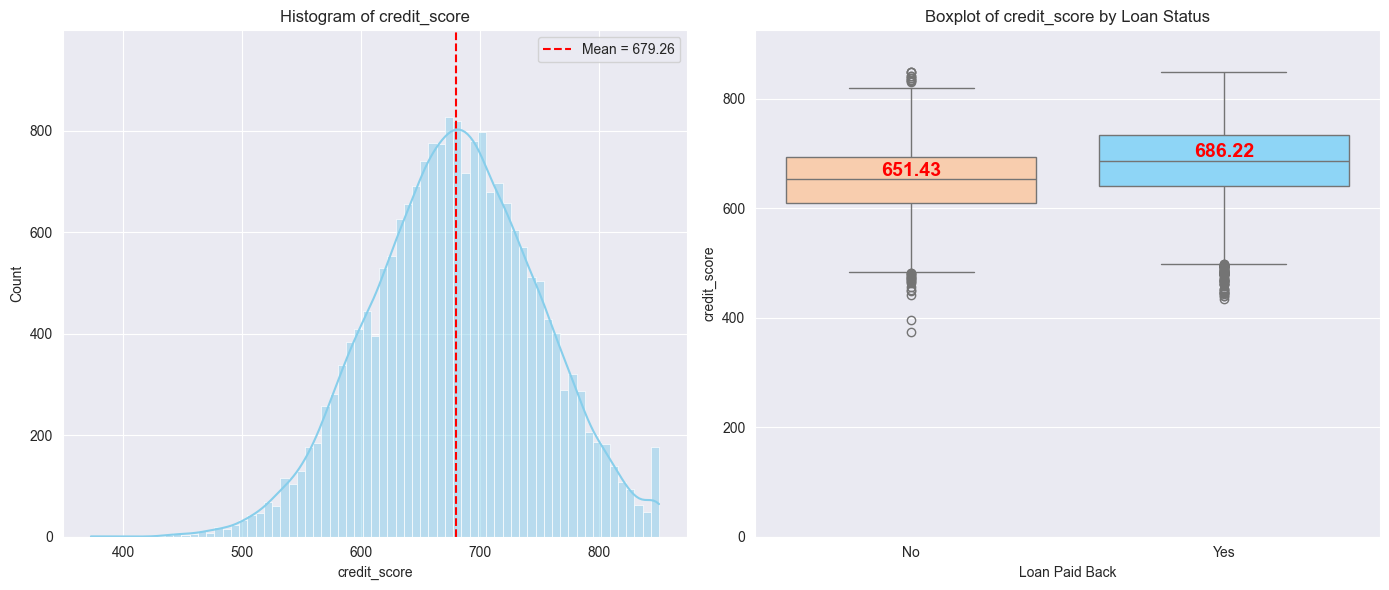

In [137]:
statistical_summary_for_numerical('credit_score')
plot_numerical_distribution('credit_score')

##### 🔍 **Credit Score** — Analysis Summary

- **Distribution** : Roughly symmetric (skew = -0.07, Mean ≈ Median ≈ 679–680), well-behaved with no transformation needed — dataset borrowers average in the "Good" credit range (670–739)
- **Spread** : Moderate dispersion (std = 69.64, IQR = 632 – 727), covering Fair to Very Good credit range for most borrowers
- **vs Loan Status** : Clear and meaningful separation — Not Paid mean (651, "Fair") vs Paid mean (686, "Good"), a difference of 34.78 points — borrowers who defaulted averaged in the Fair credit tier while those who repaid averaged in the Good tier
- **Key Pattern** : Higher credit scores are associated with better repayment — fully aligned with real-world expectations, where credit score was designed precisely to predict this behavior
- **Statistical Test** : T-test p = 0.0000 ✅ — difference between groups is highly statistically significant
- **Correlation** : Point-biserial r = 0.200 — moderate positive relationship, meaning higher credit score is associated with higher likelihood of repayment
- **Conclusion** : `credit_score` has a **meaningful and statistically strong relationship** with loan repayment — a well-known predictor in credit risk, expected to be one of the most valuable features in modeling

#### 10. Distribution of loan_amount


    ─────────────────────────────────────────────
    📊 Summary for 'loan_amount'
    ─────────────────────────────────────────────
    Range     : 500.00  →  49039.69
    Mean      : 15129.30
    Median    : 14946.17
    Std Dev   : 8605.41
    IQR       : 8852.69  →  20998.87
    Skewness  : 0.25  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 15172.13
    Loan Paid     (1) mean : 15118.59
    Difference            : 53.55
    ─────────────────────────────────────────────
    T-test p-value        : 0.7248  ❌ Not significant
    Point-biserial corr   : -0.0025  (p=0.7248)
    ─────────────────────────────────────────────
    


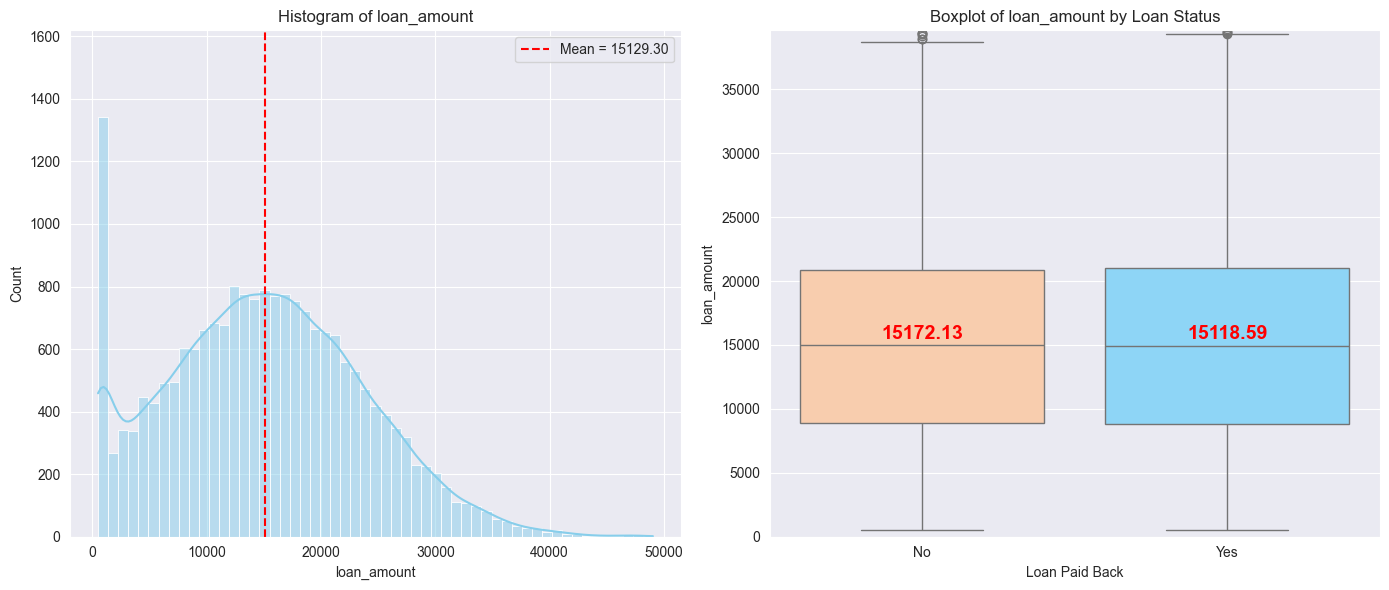

In [138]:
statistical_summary_for_numerical('loan_amount')
plot_numerical_distribution('loan_amount')

##### 🔍 **Loan Amount** — Analysis Summary

- **Distribution** : Roughly symmetric (skew = 0.25, Mean ≈ Median ≈ 15,129 – 14,946), bimodal shape visible in histogram suggesting two common borrowing patterns (small loans ~2,000 and mid-range loans ~15,000–20,000); no transformation needed
- **Spread** : Wide but reasonable dispersion (std = $8,605, IQR = $8,853 – $20,999), ranging from $500 to $49,040
- **vs Loan Status** : Virtually identical between groups — Not Paid ($15,172) vs Paid ($15,119), a negligible difference of only $53
- **Key Pattern** : No visible separation in boxplot — both groups overlap almost perfectly, suggesting loan amount alone does not influence repayment behavior
- **Statistical Test** : T-test p = 0.725 ❌ — difference between groups is not statistically significant
- **Correlation** : Point-biserial r = -0.003 — essentially zero, confirms no linear relationship with loan repayment
- **Conclusion** : `loan_amount` has **no meaningful relationship** with loan repayment — not expected to contribute predictive power to the model

#### 11. Distribution of loan_purpose


──────────────────────────────────────────────────
📊 Summary for 'loan_purpose'
──────────────────────────────────────────────────
Total Unique Values : 8
──────────────────────────────────────────────────
Value Distribution:
  debt_consolidation Count: 7981     (39.91%)
  other           Count: 2550     (12.75%)
  car             Count: 2390     (11.95%)
  home            Count: 1972     (9.86%)
  education       Count: 1675     (8.38%)
  business        Count: 1629     (8.14%)
  medical         Count: 1196     (5.98%)
  vacation        Count: 607      (3.03%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         debt_consolidationother          car            home           education      business       medical        vacation       
  ···············································································································································
  Not Paid (0)        20.06%        19.73%        20.1

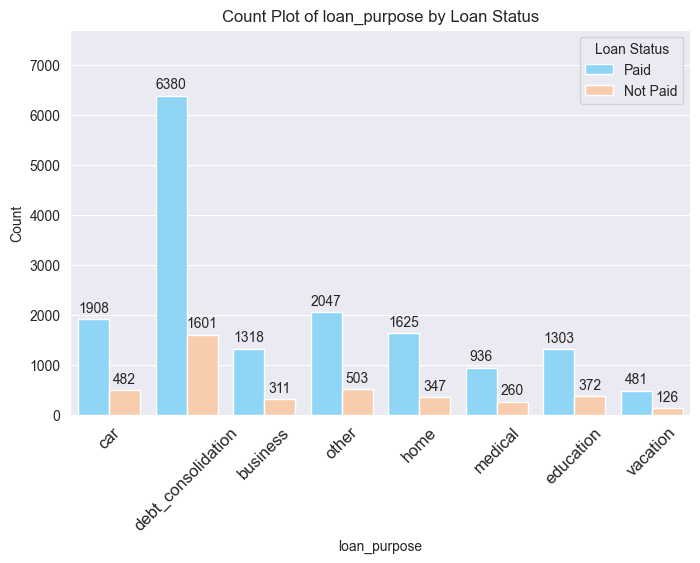

In [139]:
statistical_summary_for_categorical('loan_purpose')
plot_categorical_distribution('loan_purpose')

##### 🔍 **Loan Purpose** — Analysis Summary

- **Distribution** : Dominated by debt consolidation (39.91%), followed by other (12.75%), car (11.95%), home (9.86%), education (8.38%), business (8.14%), medical (5.98%), and vacation (3.03%)
- **vs Loan Status** : Repayment rates are consistently similar across all purposes — Home loans lead slightly (82.40%) while Education loans lag (77.79%), but overall spread is only ~4.6 percentage points
- **Statistical Test** : Chi-squared p = 0.0278 ✅ — statistically significant association exists
- **Effect Size** : Cramér's V = √(15.721 / 20000 × (8−1)) ≈ √(15.721 / 140000) ≈ **0.0335 — Negligible effect**, large dataset detecting a practically meaningless difference
- **Conclusion** : `loan_purpose` has a **statistically significant but negligible practical effect** on loan repayment — similar to `education_level`, the p-value is driven by dataset size rather than a real signal; unlikely to contribute meaningful predictive power to the model

#### 12. Distribution of interest_rate


    ─────────────────────────────────────────────
    📊 Summary for 'interest_rate'
    ─────────────────────────────────────────────
    Range     : 3.14  →  22.51
    Mean      : 12.40
    Median    : 12.40
    Std Dev   : 2.44
    IQR       : 10.74  →  14.00
    Skewness  : 0.03  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 12.94
    Loan Paid     (1) mean : 12.27
    Difference            : 0.68
    ─────────────────────────────────────────────
    T-test p-value        : 0.0000  ✅ Significant
    Point-biserial corr   : -0.1109  (p=0.0000)
    ─────────────────────────────────────────────
    


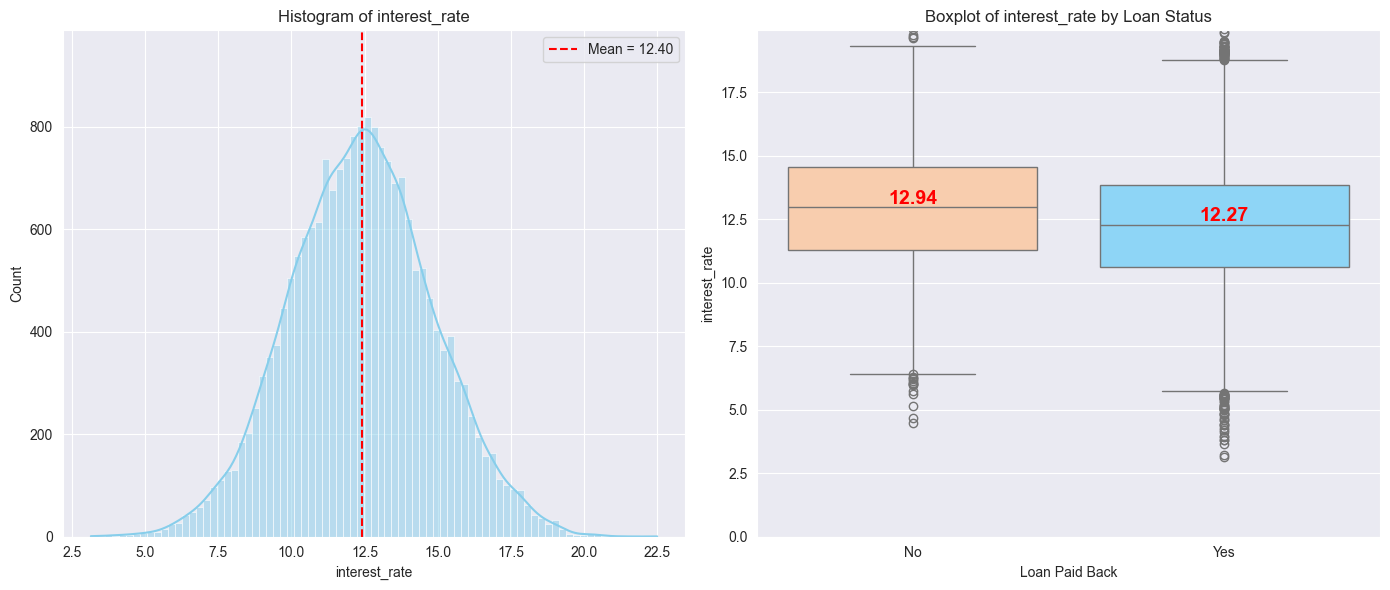

In [140]:
statistical_summary_for_numerical('interest_rate')
plot_numerical_distribution('interest_rate')

##### 🔍 **Interest Rate** — Analysis Summary

- **Distribution** : Nearly perfectly symmetric (skew = 0.03, Mean = Median = 12.40), well-behaved normal-like distribution — no transformation needed
- **Spread** : Tight dispersion (std = 2.44, IQR = 10.74 – 14.00), most borrowers clustered between 10–14% interest
- **vs Loan Status** : Visible separation between groups — Not-Paid mean (12.94%) vs Paid mean (12.27%), a difference of 0.68 percentage points; higher interest rate associated with default
- **Key Pattern** : Intuitive and expected — borrowers assigned **higher interest rates** (typically reflecting higher perceived risk by the lender) are more likely to default, suggesting interest rate partially encodes the lender's own risk assessment
- **Statistical Test** : T-test p = 0.0000 ✅ — difference between groups is highly statistically significant
- **Correlation** : Point-biserial r = -0.111 — weak negative relationship, meaning higher interest rate is associated with lower likelihood of repayment
- **Conclusion** : `interest_rate` has a **weak but statistically significant relationship** with loan repayment — a reliable predictor with a consistent directional signal; expected to contribute moderate predictive power to the model

#### 13. Distribution of loan_term


──────────────────────────────────────────────────
📊 Summary for 'loan_term'
──────────────────────────────────────────────────
Total Unique Values : 2
──────────────────────────────────────────────────
Value Distribution:
  36              Count: 13981    (69.91%)
  60              Count: 6019     (30.09%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         36             60             
  ··················································
  Not Paid (0)        19.94%        20.17%        
  Paid     (1)        80.06%        79.83%        
──────────────────────────────────────────────────
Chi-squared : 0.1229
p-value     : 0.7259  ❌ Not significant
Degrees of Freedom : 1
──────────────────────────────────────────────────



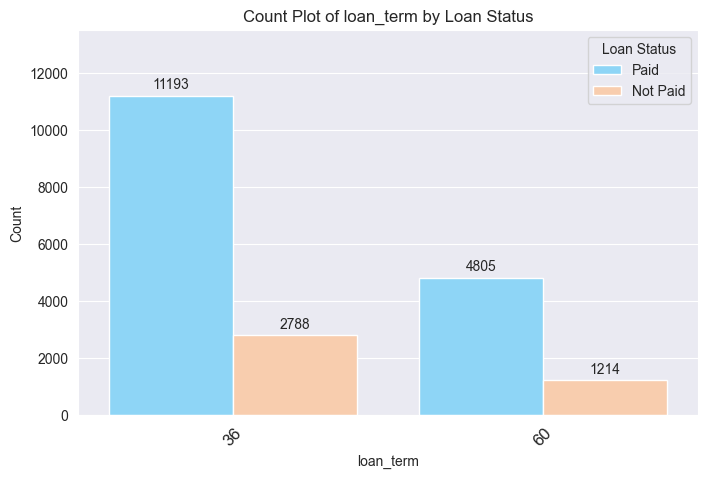

In [141]:
statistical_summary_for_categorical("loan_term")
plot_categorical_distribution("loan_term")

##### 🔍 **Loan Term** — Analysis Summary

- **Distribution** : Majority of borrowers on 36-month terms (69.91%) vs 60-month terms (30.09%) — a roughly 70/30 split
- **vs Loan Status** : Repayment rates are virtually identical between terms — 36-month (80.06%) vs 60-month (79.83%), a negligible difference of only 0.23 percentage points
- **Statistical Test** : Chi-squared p = 0.726 ❌ — no statistically significant association with loan repayment
- **Effect Size** : Cramér's V = √(0.123 / 20000 × (2−1)) ≈ **0.0025 — Negligible**, essentially zero
- **Conclusion** : `loan_term` has **no meaningful relationship** with loan repayment — whether a borrower takes a 36 or 60-month loan makes no difference to repayment outcome; not expected to contribute predictive power to the model

#### 14. Distribution of installment


    ─────────────────────────────────────────────
    📊 Summary for 'installment'
    ─────────────────────────────────────────────
    Range     : 9.43  →  1685.40
    Mean      : 455.63
    Median    : 435.60
    Std Dev   : 274.62
    IQR       : 253.91  →  633.60
    Skewness  : 0.47  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 461.15
    Loan Paid     (1) mean : 454.24
    Difference            : 6.91
    ─────────────────────────────────────────────
    T-test p-value        : 0.1578  ❌ Not significant
    Point-biserial corr   : -0.0101  (p=0.1545)
    ─────────────────────────────────────────────
    


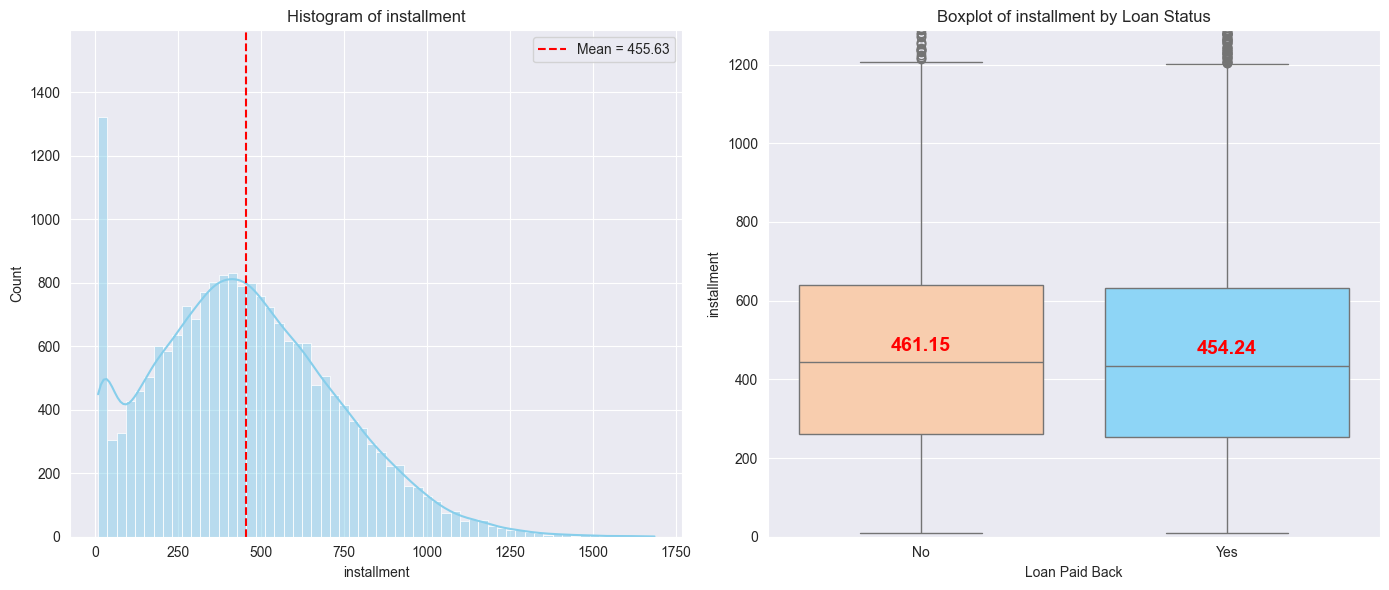

In [142]:
statistical_summary_for_numerical('installment')
plot_numerical_distribution('installment')

##### 🔍 **Installment** — Analysis Summary

- **Distribution** : Roughly symmetric (skew = 0.47, Mean ≈ Median ≈ 455–436), bimodal shape visible suggesting two common installment patterns (low ~$50 and mid-range ~$400); no transformation needed
- **Spread** : Wide dispersion (std = $274.62, IQR = $253 – $634), ranging from $9 to $1,685
- **vs Loan Status** : Virtually identical between groups — Not Paid ($461) vs Paid ($454), a negligible difference of only $6.91
- **Statistical Test** : T-test p = 0.158 ❌ — difference between groups is not statistically significant
- **Correlation** : Point-biserial r = -0.010 — essentially zero, confirms no linear relationship with loan repayment
- **Conclusion** : `installment` has **no meaningful relationship** with loan repayment — monthly payment amount alone does not influence repayment outcome; not expected to contribute predictive power to the model

#### 15. Distribution of num_of_open_accounts

⚠ Low expected cell counts — chi² may be unreliable

──────────────────────────────────────────────────
📊 Summary for 'num_of_open_accounts'
──────────────────────────────────────────────────
Total Unique Values : 16
──────────────────────────────────────────────────
Value Distribution:
  5               Count: 3533     (17.66%)
  4               Count: 3516     (17.58%)
  6               Count: 2868     (14.34%)
  3               Count: 2770     (13.85%)
  7               Count: 2112     (10.56%)
  2               Count: 1672     (8.36%)
  8               Count: 1317     (6.59%)
  9               Count: 750      (3.75%)
  1               Count: 691      (3.45%)
  10              Count: 359      (1.80%)
  11              Count: 157      (0.78%)
  0               Count: 129      (0.65%)
  12              Count: 86       (0.43%)
  13              Count: 28       (0.14%)
  14              Count: 9        (0.04%)
  15              Count: 3        (0.01%)
───────────────────────────────────

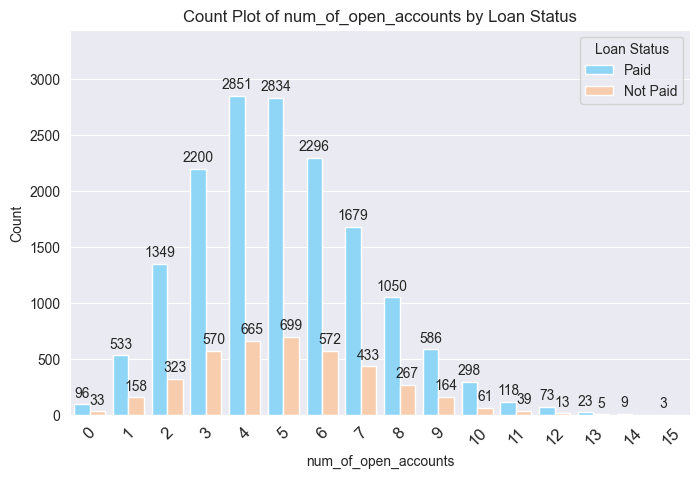

In [143]:
statistical_summary_for_categorical('num_of_open_accounts')
plot_categorical_distribution('num_of_open_accounts')

##### 🔍 **Number of Open Accounts** — Analysis Summary

- **Distribution** : Roughly bell-shaped, concentrated between 3–7 accounts (74% of borrowers), with very sparse counts at extremes (0, 13–15 accounts); 16 unique values
- **vs Loan Status** : Repayment rates are largely consistent across account counts — ranging from ~75% to ~85%, with no clear directional trend; extreme values (14, 15) show 100% paid but are too sparse to be meaningful (only 12 records combined)
- **Statistical Test** : Chi-squared p = 0.152 ❌ — not statistically significant; additionally ⚠️ low expected cell counts at extremes make the chi² result unreliable
- **Effect Size** : Cramér's V = √(20.53 / 20000 × 15) ≈ **0.0083 — Negligible**
- **Conclusion** : `num_of_open_accounts` has **no meaningful relationship** with loan repayment — not expected to contribute predictive power to the model

#### 16. Distribution of total_credit_limit


    ─────────────────────────────────────────────
    📊 Summary for 'total_credit_limit'
    ─────────────────────────────────────────────
    Range     : 6157.80  →  454394.19
    Mean      : 48649.82
    Median    : 40241.61
    Std Dev   : 32423.38
    IQR       : 27180.49  →  60361.26
    Skewness  : 2.49  (high right skew)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 48843.33
    Loan Paid     (1) mean : 48601.42
    Difference            : 241.91
    ─────────────────────────────────────────────
    T-test p-value        : 0.6870  ❌ Not significant
    Point-biserial corr   : -0.0030  (p=0.6729)
    ─────────────────────────────────────────────
    


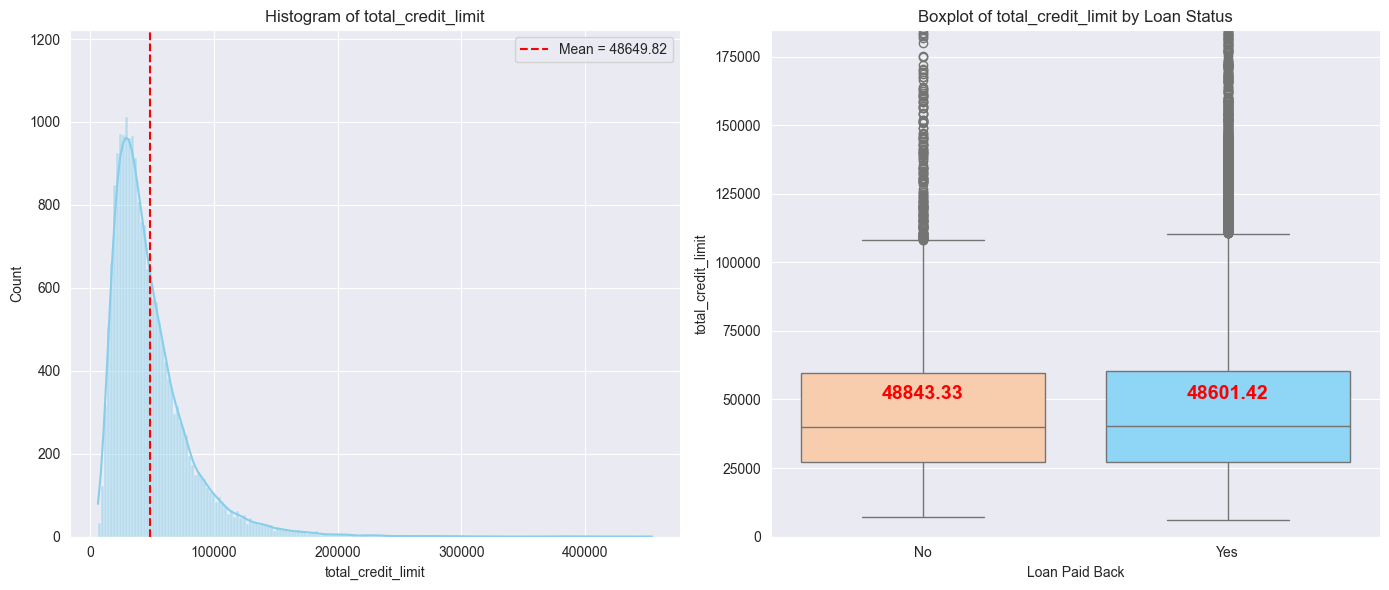

In [144]:
statistical_summary_for_numerical('total_credit_limit')
plot_numerical_distribution('total_credit_limit')


    ─────────────────────────────────────────────
    📊 Summary for 'total_credit_limit_log'
    ─────────────────────────────────────────────
    Range     : 8.73  →  13.03
    Mean      : 10.62
    Median    : 10.60
    Std Dev   : 0.58
    IQR       : 10.21  →  11.01
    Skewness  : 0.15  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 10.62
    Loan Paid     (1) mean : 10.62
    Difference            : 0.00
    ─────────────────────────────────────────────
    T-test p-value        : 0.9362  ❌ Not significant
    Point-biserial corr   : 0.0006  (p=0.9363)
    ─────────────────────────────────────────────
    


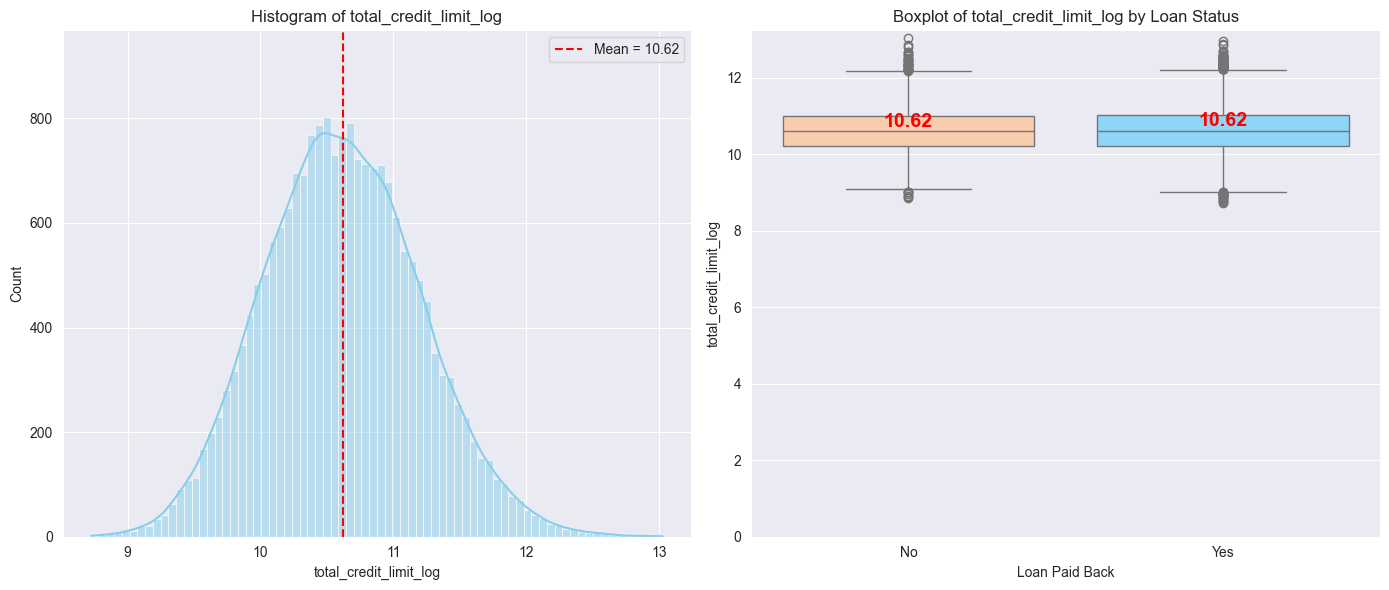

In [145]:
# total_credit_limit log-transform
total_credit_limit_log = np.log1p(df['total_credit_limit'])
df['total_credit_limit_log'] = total_credit_limit_log
statistical_summary_for_numerical('total_credit_limit_log')
plot_numerical_distribution('total_credit_limit_log')


##### 🔍 **Total Credit Limit** — Analysis Summary

- **Distribution** : Heavily right-skewed in raw form (skew = 2.49), log transformation successfully normalized it (skew = 0.15) — pattern identical to `annual_income`
- **Spread** : Wide dispersion in raw form ($6,158 – $454,394), compact after log transformation (std = 0.58, IQR = 10.21 – 11.01)
- **vs Loan Status** : Both raw and log forms show virtually zero difference — Raw: $48,843 vs $48,601 (diff = $241); Log: 10.62 vs 10.62 (diff = 0.00)
- **Statistical Test** : Both forms not significant — Raw p = 0.687 ❌, Log p = 0.936 ❌
- **Correlation** : Point-biserial r = -0.003 (raw) and 0.001 (log) — essentially zero in both forms
- **Conclusion** : `total_credit_limit` has **no meaningful relationship** with loan repayment in any form — log transformation confirmed no hidden signal exists

#### 17. Distribution of current_balance


    ─────────────────────────────────────────────
    📊 Summary for 'current_balance'
    ─────────────────────────────────────────────
    Range     : 496.35  →  352177.90
    Mean      : 24333.39
    Median    : 18334.56
    Std Dev   : 22313.85
    IQR       : 9592.57  →  31743.33
    Skewness  : 2.79  (high right skew)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 24545.25
    Loan Paid     (1) mean : 24280.40
    Difference            : 264.85
    ─────────────────────────────────────────────
    T-test p-value        : 0.5106  ❌ Not significant
    Point-biserial corr   : -0.0047  (p=0.5019)
    ─────────────────────────────────────────────
    


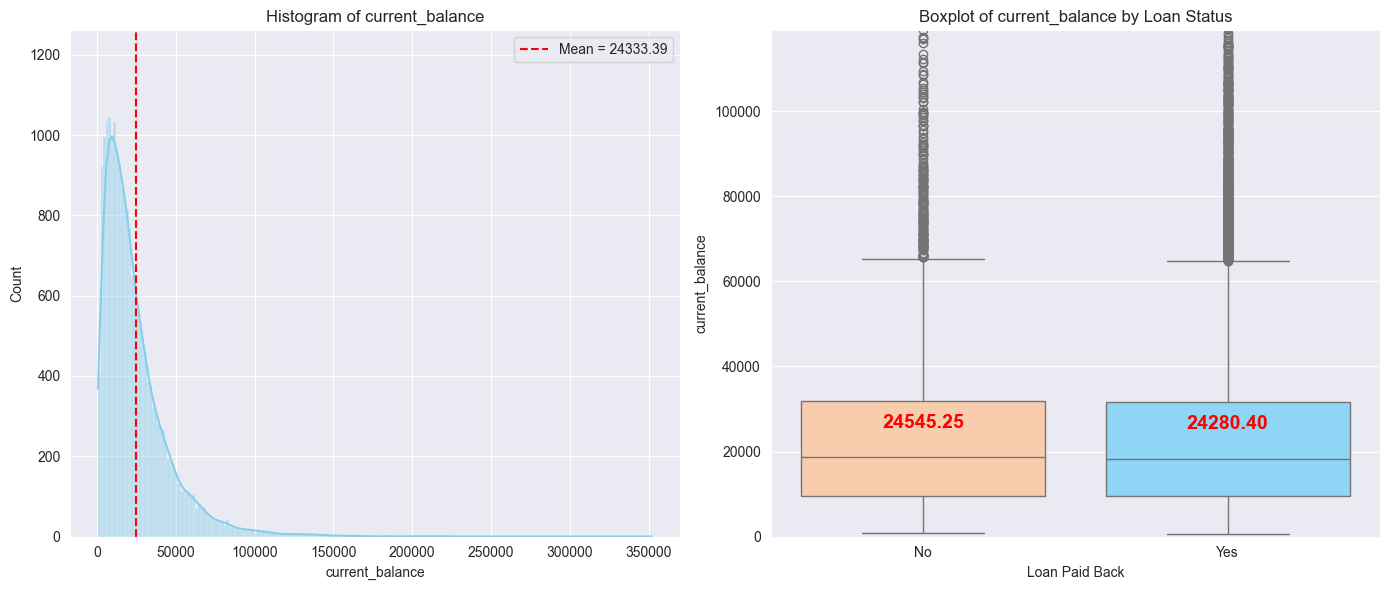

In [146]:
statistical_summary_for_numerical('current_balance')
plot_numerical_distribution('current_balance')


    ─────────────────────────────────────────────
    📊 Summary for 'current_balance_log'
    ─────────────────────────────────────────────
    Range     : 6.21  →  12.77
    Mean      : 9.73
    Median    : 9.82
    Std Dev   : 0.91
    IQR       : 9.17  →  10.37
    Skewness  : -0.40  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 9.74
    Loan Paid     (1) mean : 9.73
    Difference            : 0.01
    ─────────────────────────────────────────────
    T-test p-value        : 0.5371  ❌ Not significant
    Point-biserial corr   : -0.0044  (p=0.5381)
    ─────────────────────────────────────────────
    


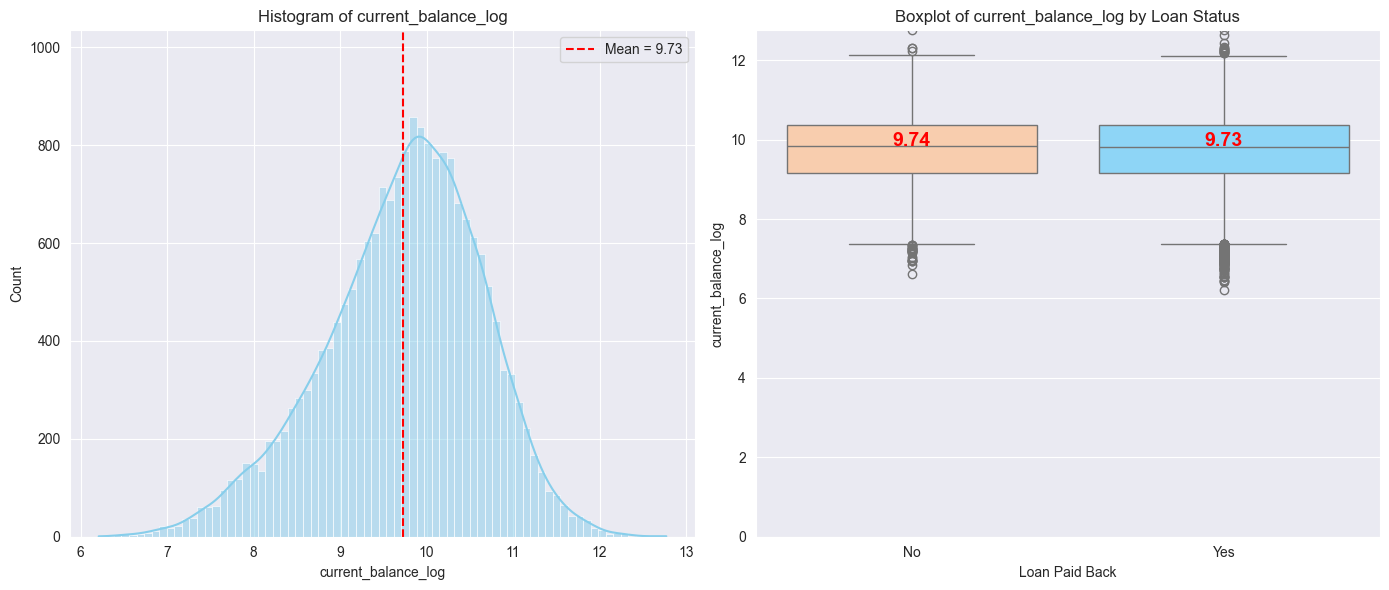

In [147]:
#current_balance log-transform
current_balance_log = np.log1p(df['current_balance'])
df['current_balance_log'] = current_balance_log
statistical_summary_for_numerical('current_balance_log')
plot_numerical_distribution('current_balance_log')


##### 🔍 **Current Balance (Log-Transformed)** — Analysis Summary

- **Distribution** : Roughly symmetric after log transformation (skew = -0.40, Mean ≈ Median ≈ 9.73–9.82) — well-behaved, no further transformation needed
- **Spread** : Moderate dispersion (std = 0.91, IQR = 9.17 – 10.37)
- **vs Loan Status** : Identical between groups — Not Paid (9.74) vs Paid (9.73), difference of only 0.01; boxplots completely overlap
- **Statistical Test** : T-test p = 0.537 ❌ — not statistically significant
- **Correlation** : Point-biserial r = -0.004 — essentially zero, no linear relationship with loan repayment
- **Conclusion** : `current_balance_log` has **no meaningful relationship** with loan repayment — **recommend dropping both `current_balance` and `current_balance_log`** from modeling

#### 18. Distribution of num_of_delinquencies


    ─────────────────────────────────────────────
    📊 Summary for 'num_of_delinquencies'
    ─────────────────────────────────────────────
    Range     : 0.00  →  11.00
    Mean      : 2.49
    Median    : 2.00
    Std Dev   : 1.63
    IQR       : 1.00  →  3.00
    Skewness  : 0.72  (moderate right skew)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 2.72
    Loan Paid     (1) mean : 2.43
    Difference            : 0.29
    ─────────────────────────────────────────────
    T-test p-value        : 0.0000  ✅ Significant
    Point-biserial corr   : -0.0709  (p=0.0000)
    ─────────────────────────────────────────────
    


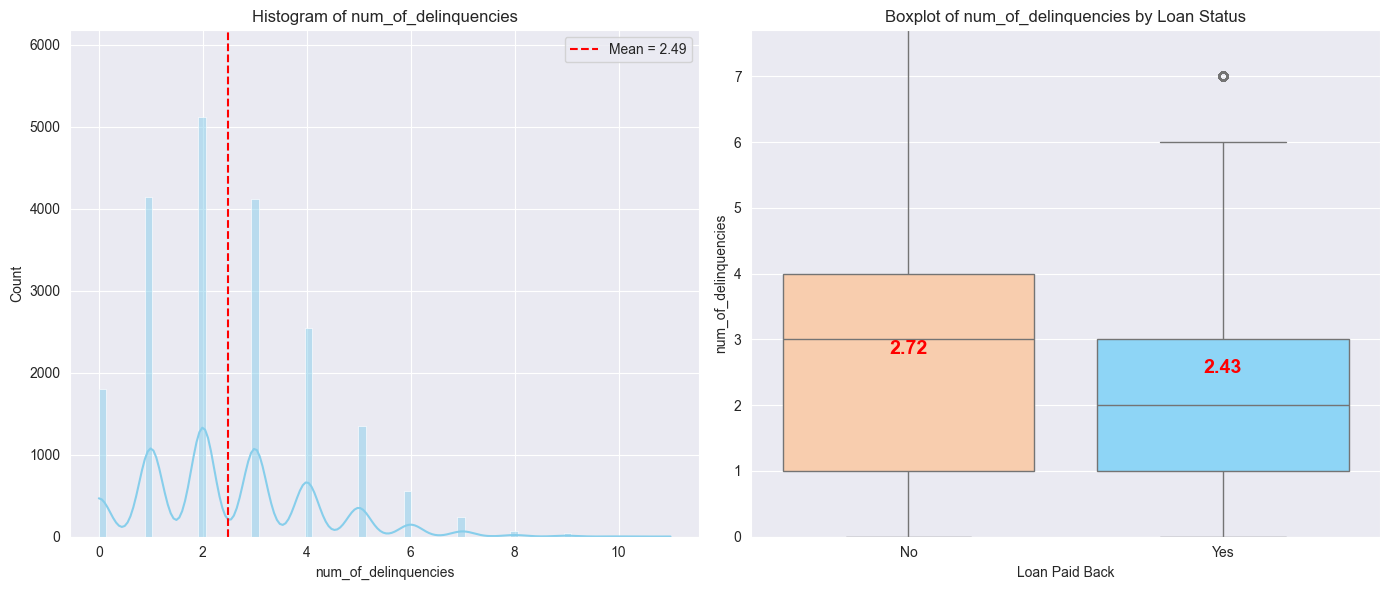

In [148]:
statistical_summary_for_numerical('num_of_delinquencies')
plot_numerical_distribution('num_of_delinquencies')

##### 🔍 **Number of Delinquencies** — Analysis Summary

- **Distribution** : Discrete count variable with multimodal pattern (peaks at 0, 1, 2, 4), moderate right skew (0.72) — typical for count data; no transformation needed
- **Spread** : Relatively compact (std = 1.63, IQR = 1–3), most borrowers have 0–4 delinquencies with rare cases up to 11
- **vs Loan Status** : Visible separation in boxplot — Not Paid mean (2.72) vs Paid mean (2.43), difference of 0.29; defaulters consistently carry more delinquencies
- **Key Pattern** : Expected and intuitive — borrowers with **more past delinquencies** are more likely to default again, confirming past repayment behavior predicts future behavior
- **Statistical Test** : T-test p = 0.0000 ✅ — highly statistically significant
- **Correlation** : Point-biserial r = -0.071 — small negative relationship, meaning more delinquencies associated with lower repayment likelihood
- **Conclusion** : `num_of_delinquencies` has a **weak but statistically significant relationship** with loan repayment — effect is modest but directionally consistent and meaningful; worth keeping as a feature in modeling